1.Install and Import Libraries

In [4]:
!pip install yfinance

In [6]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Set a professional plotting style for better visuals
plt.style.use('seaborn-v0_8-darkgrid')

2.Configuration and Key Parameters

In [9]:
# 1. Define the list of US stock tickers to analyze.
tickers = ['AAPL', 'MSFT', 'AMZN', 'GOOG', 'TSLA', 'NVDA']

# 2. Define the market index (S&P 500) as our benchmark
market_index = '^GSPC' # S&P 500 index

# 3. Set the start and end dates for our historical data (5 years)
#    This provides a robust period for analysis.
end_date = pd.to_datetime('today').strftime('%Y-%m-%d')
start_date = (pd.to_datetime('today') - pd.DateOffset(years=5)).strftime('%Y-%m-%d')

# 4. Set the Risk-Free Rate (Rf)
#    This is typically the yield on the 10-year US Treasury bond.
#    A reasonable estimate for late 2025 is 4.5%.
risk_free_rate = 0.045

print(f"Analysis period set from {start_date} to {end_date}.")

Analysis period set from 2021-03-31 to 2026-03-31.


3.Download Historical Stock and Market Data

In [10]:
# Add the market index to our list of tickers to download all data in one go
all_tickers = tickers + [market_index]

# Download all available price data
data = yf.download(all_tickers, start=start_date, end=end_date)

# Drop any rows with missing data to ensure data quality
data.dropna(inplace=True)

# Select the 'Close' column from the MultiIndex DataFrame
adjusted_close_prices = data['Close']

# Display the first few rows and column names to identify the correct column for adjusted close prices
print("Downloaded Price Data (First 5 Rows):")
print(adjusted_close_prices.head())
print("\nColumn Names:")
print(adjusted_close_prices.columns)

/tmp/ipykernel_6045/825416955.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(all_tickers, start=start_date, end=end_date)
[*********************100%***********************]  7 of 7 completed

Downloaded Price Data (First 5 Rows):
Ticker            AAPL        AMZN        GOOG        MSFT       NVDA  \
Date                                                                    
2021-03-31  118.973572  154.703995  102.589249  226.235321  13.314691   
2021-04-01  119.801460  158.050003  106.017097  232.549286  13.777028   
2021-04-05  122.626038  161.336502  110.371346  238.997498  13.952335   
2021-04-06  122.927994  161.190994  110.331680  237.836456  13.826652   
2021-04-07  124.574051  163.969498  111.568039  239.793930  14.107942   

Ticker            TSLA        ^GSPC  
Date                                 
2021-03-31  222.643326  3972.889893  
2021-04-01  220.583328  4019.870117  
2021-04-05  230.350006  4077.909912  
2021-04-06  230.539993  4073.939941  
2021-04-07  223.656662  4079.949951  

Column Names:
Index(['AAPL', 'AMZN', 'GOOG', 'MSFT', 'NVDA', 'TSLA', '^GSPC'], dtype='object', name='Ticker')


4.Calculate Daily Returns

In [11]:
# Use the pct_change() method to calculate daily returns
returns = data.pct_change()

# Drop the first row of returns as it will be NaN (no previous day to compare)
returns.dropna(inplace=True)

# Separate the market returns from the individual stock returns
market_returns = returns['Close'].drop(columns=[market_index])
stock_returns = returns['Close'].drop(columns=[market_index])

print("\nCalculated Daily Returns ( 5 Rows):")
print(stock_returns.tail())
print("\nCalculated Daily Returns ( 5 Rows):")
print(market_returns.tail())



Calculated Daily Returns ( 5 Rows):
Ticker          AAPL      AMZN      GOOG      MSFT      NVDA      TSLA
Date                                                                  
2026-03-24  0.000596 -0.013800 -0.032841 -0.026789 -0.002505  0.005724
2026-03-25  0.003894  0.021569  0.001348 -0.004561  0.019863  0.007623
2026-03-26  0.001069 -0.019697 -0.030560 -0.013664 -0.041639 -0.035860
2026-03-27 -0.016173 -0.039510 -0.024863 -0.025139 -0.021724 -0.027626
2026-03-30 -0.008722  0.008077 -0.002265  0.006138 -0.014028 -0.018102

Calculated Daily Returns ( 5 Rows):
Ticker          AAPL      AMZN      GOOG      MSFT      NVDA      TSLA
Date                                                                  
2026-03-24  0.000596 -0.013800 -0.032841 -0.026789 -0.002505  0.005724
2026-03-25  0.003894  0.021569  0.001348 -0.004561  0.019863  0.007623
2026-03-26  0.001069 -0.019697 -0.030560 -0.013664 -0.041639 -0.035860
2026-03-27 -0.016173 -0.039510 -0.024863 -0.025139 -0.021724 -0.027626
202

5.Calculate Beta for Each Stock

In [12]:
# Create an empty dictionary to store the calculated beta for each stock
betas = {}

# Explicitly define the market's return series (a single column)
market_series = returns['Close'][market_index]

# Calculate the variance of the market returns
market_variance = market_series.var()

print(f"\nCalculating Betas against market index '{market_index}'...")

# Loop through each stock ticker in the columns of our stock_returns DataFrame
for stock_ticker in stock_returns.columns:

    # Explicitly define the stock's return series (a single column)
    stock_series = stock_returns[stock_ticker]

    # Calculate covariance between the single stock series and the single market series
    covariance = stock_series.cov(market_series)

    # Calculate beta and store it
    beta = covariance / market_variance
    betas[stock_ticker] = beta

print("\nCalculated Betas:")
for stock, beta in betas.items():
    print(f"{stock}: {beta:.2f}")


Calculating Betas against market index '^GSPC'...

Calculated Betas:
AAPL: 1.23
AMZN: 1.50
GOOG: 1.25
MSFT: 1.16
NVDA: 2.17
TSLA: 2.01


Calculate Alpha for Each Stock

In [13]:
# Calculate the average daily returns for each stock and the market
average_stock_returns = stock_returns.mean()
average_market_return = market_series.mean()

# Calculate the average daily risk-free rate
# Convert the annual risk-free rate to a daily rate assuming 252 trading days in a year
average_daily_risk_free_rate = risk_free_rate / 252

# Create an empty dictionary to store the calculated alpha for each stock
alpha_values = {}

print(f"\nCalculating Alphas with a risk-free rate of {risk_free_rate*100:.2f}% (annual)...")

# Loop through each stock ticker and its calculated beta
for stock_ticker, beta in betas.items():
    # Calculate the expected return using the CAPM model
    expected_return = average_daily_risk_free_rate + beta * (average_market_return - average_daily_risk_free_rate)

    # Calculate Alpha
    alpha = average_stock_returns[stock_ticker] - expected_return
    alpha_values[stock_ticker] = alpha

print("\nCalculated Alphas:")
for stock, alpha in alpha_values.items():
    print(f"{stock}: {alpha:.6f}")


Calculating Alphas with a risk-free rate of 4.50% (annual)...

Calculated Alphas:
AAPL: 0.000243
AMZN: -0.000099
GOOG: 0.000474
MSFT: 0.000035
NVDA: 0.001812
TSLA: 0.000377


6.Calculate Performance and Generate Forecast

In [14]:
# First, calculate the annualized market return and the market risk premium
# We multiply by 252, the typical number of trading days in a year.
annualized_market_return = market_series.mean() * 252
market_risk_premium = annualized_market_return - risk_free_rate


print(f"\nAnnualized Market Return (Nifty 50): {annualized_market_return:.2%}")
print(f"Market Risk Premium (Market Return - Risk-Free Rate): {market_risk_premium:.2%}")


# Create a list to hold the final results for our summary
results = []


for stock, beta in betas.items():
    # 1. Calculate the stock's actual annualized historical return
    actual_return = stock_returns[stock].mean() * 252


    # 2. Calculate the CAPM required return (the "fair" return)
    capm_return = risk_free_rate + beta * market_risk_premium


    # 3. THE FORECAST: Compare actual return to the CAPM return
    if actual_return > capm_return:
        forecast = 'Buy / Bullish (Undervalued)'
    else:
        forecast = 'Sell / Bearish (Overvalued)'


    results.append({
        'Stock': stock,
        'Beta': beta,
        'Actual_Return': actual_return,
        'CAPM_Return': capm_return,
        'Forecast': forecast
    })




Annualized Market Return (Nifty 50): 10.83%
Market Risk Premium (Market Return - Risk-Free Rate): 6.33%


7.Final Summary Table

In [15]:

summary_df = pd.DataFrame(results)

# Create a display-friendly version with formatted percentages
summary_df_display = summary_df.copy()
summary_df_display['Actual_Return'] = summary_df_display['Actual_Return'].map('{:.2%}'.format)
summary_df_display['CAPM_Return'] = summary_df_display['CAPM_Return'].map('{:.2%}'.format)
summary_df_display['Beta'] = summary_df_display['Beta'].map('{:.2f}'.format)

print("\n--- Project Analysis Summary ---")
display(summary_df_display[['Stock', 'Beta', 'Actual_Return', 'CAPM_Return', 'Forecast']])


--- Project Analysis Summary ---


,Stock,Beta,Actual_Return,CAPM_Return,Forecast
0,AAPL,1.23,18.40%,12.28%,Buy / Bullish (Undervalued)
1,AMZN,1.50,11.48%,13.96%,Sell / Bearish (Overvalued)
2,GOOG,1.25,24.37%,12.43%,Buy / Bullish (Undervalued)
3,MSFT,1.16,12.70%,11.81%,Buy / Bullish (Undervalued)
4,NVDA,2.17,63.87%,18.21%,Buy / Bullish (Undervalued)
5,TSLA,2.01,26.73%,17.23%,Buy / Bullish (Undervalued)


8.Visualization with the Security market Line(SML)

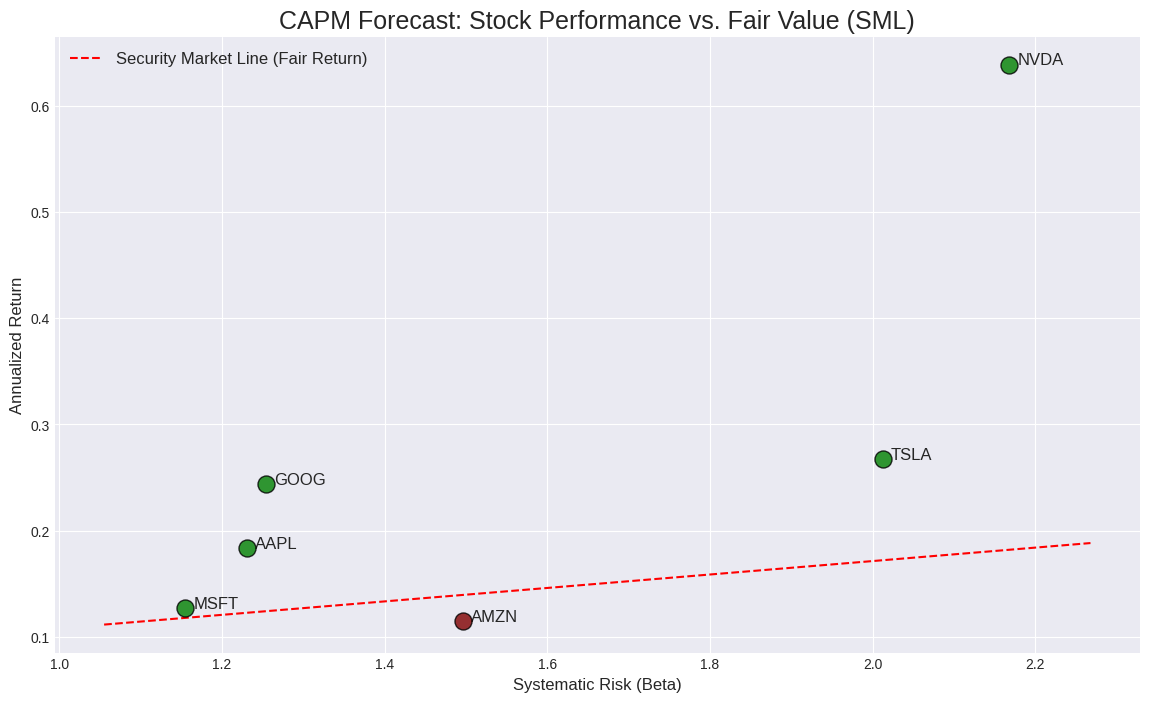

In [16]:
plt.figure(figsize=(14, 8))

# 1. Plot the Security Market Line (SML) - our "Fair Deal Line"
beta_range = np.linspace(summary_df['Beta'].min() - 0.1, summary_df['Beta'].max() + 0.1, 100)
sml_line = risk_free_rate + beta_range * market_risk_premium
plt.plot(beta_range, sml_line, color='red', linestyle='--', label='Security Market Line (Fair Return)')

# 2. Plot each stock's position and color-code the forecast
for i, row in summary_df.iterrows():
    color = 'green' if 'Buy' in row['Forecast'] else 'maroon'
    plt.scatter(row['Beta'], row['Actual_Return'], s=150, zorder=5, color=color, edgecolors='black', alpha=0.8)
    plt.text(row['Beta'] + 0.01, row['Actual_Return'], f"{row['Stock']}", fontsize=12)

# 3. Format the chart for a professional presentation
plt.title('CAPM Forecast: Stock Performance vs. Fair Value (SML)', fontsize=18)
plt.xlabel('Systematic Risk (Beta)', fontsize=12)
plt.ylabel('Annualized Return', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True)
plt.show()

In [17]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd
import numpy as np
import yfinance as yf

# Define the list of NSE stock tickers and market index
tickers = ['RELIANCE.NS', 'TCS.NS', 'HDFCBANK.NS', 'INFY.NS', 'BHARTIARTL.NS', 'ITC.NS']
market_index = '^NSEI'

# Define the start and end dates for historical data
end_date = pd.to_datetime('today').strftime('%Y-%m-%d')
start_date = (pd.to_datetime('today') - pd.DateOffset(years=5)).strftime('%Y-%m-%d')

# Set the Risk-Free Rate (Rf)
risk_free_rate = 0.070

# ---  Create and Display the Dashboard ---
print("Generating dashboard...")
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        "1. Cumulative Returns (vs. Nifty 50)",
        "2. Risk vs. Return (CAPM Analysis)",
        "3. Beta (Systematic Risk)",
        "4. Annualized Alpha (Excess Return)"
    ),
    specs=[[{}, {}], [{}, {}]]
)

# Download the data again within this cell
all_tickers = tickers + [market_index]
data = yf.download(all_tickers, start=start_date, end=end_date)
data.dropna(inplace=True)

# Calculate daily returns on the 'Close' price
returns = data['Close'].pct_change().dropna()

# Separate stock and market returns
stock_returns = returns.drop(columns=[market_index])
market_series = returns[market_index]


# Calculate Beta
betas = {}
market_variance = market_series.var()
for stock_ticker in stock_returns.columns:
    covariance = stock_returns[stock_ticker].cov(market_series)
    beta = covariance / market_variance
    betas[stock_ticker] = beta

# Calculate Alpha
average_stock_returns = stock_returns.mean()
average_market_return = market_series.mean()
average_daily_risk_free_rate = risk_free_rate / 252
alpha_values = {}
for stock_ticker, beta in betas.items():
    expected_return = average_daily_risk_free_rate + beta * (average_market_return - average_daily_risk_free_rate)
    alpha = average_stock_returns[stock_ticker] - expected_return
    alpha_values[stock_ticker] = alpha

# Calculate Annualized Returns and CAPM Returns for summary_df
annualized_market_return = market_series.mean() * 252
market_risk_premium = annualized_market_return - risk_free_rate

results = []
for stock, beta in betas.items():
    actual_return = stock_returns[stock].mean() * 252
    capm_return = risk_free_rate + beta * market_risk_premium
    if actual_return > capm_return:
        forecast = 'Buy / Bullish (Undervalued)'
    else:
        forecast = 'Sell / Bearish (Overvalued)'
    results.append({
        'Stock': stock,
        'Beta': beta,
        'Actual_Return': actual_return,
        'CAPM_Return': capm_return,
        'Forecast': forecast
    })

summary_df = pd.DataFrame(results)


# Graph 1: Cumulative Returns
cumulative_returns = (1 + returns).cumprod()
fig.add_trace(go.Scatter(x=cumulative_returns.index, y=cumulative_returns[market_index],
                         mode='lines', name='Nifty 50', line=dict(color='black', dash='dash')),
              row=1, col=1)
for stock in stock_returns.columns:
    fig.add_trace(go.Scatter(x=cumulative_returns.index, y=cumulative_returns[stock],
                             mode='lines', name=stock),
                  row=1, col=1)

# Graph 2: CAPM (SML Plot)
beta_range = np.linspace(summary_df['Beta'].min() - 0.1, summary_df['Beta'].max() + 0.1, 100)
sml_line = risk_free_rate + beta_range * market_risk_premium
fig.add_trace(go.Scatter(x=beta_range, y=sml_line, mode='lines', name='Security Market Line',
                         line=dict(color='red', dash='dash')),
              row=1, col=2)
summary_df['Color'] = np.where(summary_df['Actual_Return'] > summary_df['CAPM_Return'], 'green', 'maroon')
fig.add_trace(go.Scatter(x=summary_df['Beta'], y=summary_df['Actual_Return'], mode='markers+text',
                         text=summary_df['Stock'], textposition='top right',
                         marker=dict(color=summary_df['Color'], size=10),
                         name='Stocks', showlegend=False),
              row=1, col=2)

# Graph 3: Beta
beta_df = pd.DataFrame.from_dict(betas, orient='index', columns=['Beta']).sort_values('Beta')
fig.add_trace(go.Bar(x=beta_df.index, y=beta_df['Beta'], name='Beta', showlegend=False),
              row=2, col=1)

# Graph 4: Alpha
alpha_df = pd.DataFrame.from_dict(alpha_values, orient='index', columns=['Alpha']).sort_values('Alpha')
colors = ['green' if x > 0 else 'maroon' for x in alpha_df['Alpha']]
fig.add_trace(go.Bar(x=alpha_df.index, y=alpha_df['Alpha'], marker_color=colors, name='Alpha', showlegend=False),
              row=2, col=2)
fig.add_hline(y=0, line_width=1, line_dash="dash", line_color="black", row=2, col=2)

# Update Layout
fig.update_layout(
    title_text="Comprehensive Stock Analysis Dashboard",
    height=700, # Reduced height to better fit the output cell
    xaxis1_title="Date", yaxis1_title="Cumulative Growth",
    xaxis2_title="Beta (Risk)", yaxis2_title="Annualized Return",
    yaxis3_title="Beta Value",
    yaxis4_title="Annualized Alpha (%)",
    showlegend=True,
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
)
fig.update_yaxes(tickformat=".2%", row=1, col=1)
fig.update_yaxes(tickformat=".2%", row=1, col=2)
fig.update_yaxes(tickformat=".2%", row=2, col=2)

fig.show()

Generating dashboard...


/tmp/ipykernel_6045/3319945879.py:33: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  7 of 7 completed


📊 Project Summary: US Stock Performance Analysis & Forecasting (CAPM)

This project focuses on analyzing the performance of major US technology stocks using the Capital Asset Pricing Model (CAPM) to evaluate the relationship between risk and return. Historical stock data for the past five years was collected and processed using Python libraries such as Pandas, NumPy, and Matplotlib.

The project involves calculating daily and annual returns of selected stocks and comparing them with the S&P 500 as the market benchmark. Key financial metrics such as Beta (systematic risk) and Alpha (excess return) were computed to assess each stock’s performance relative to the market.

Using CAPM, expected returns were derived and visualized through the Security Market Line (SML), enabling a clear comparison between actual and expected performance. Based on this analysis, the model identifies whether stocks are undervalued (buy) or overvalued (sell).

Overall, this project demonstrates the application of financial theory, data analysis, and visualization techniques to support data-driven investment decisions.